In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# one level up to get to the question folder
Q_DIR    = os.path.normpath(os.path.join(os.getcwd(), '..', 'question'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# manual histogram equalization
# count pixel frequencies, build the CDF, then remap each intensity to spread them out
def histeq(img):
    hist    = np.bincount(img.ravel(), minlength=256).astype(np.float64)
    cdf     = hist.cumsum()
    cdf_min = cdf[cdf > 0][0]   # skip any leading zeros in the CDF
    lut     = np.round((cdf - cdf_min) / (img.size - cdf_min) * 255).astype(np.uint8)
    return lut[img]             # apply the lookup table to every pixel

In [3]:
# load runway.png and run it through our equalization
img    = cv2.imread(os.path.join(Q_DIR, 'runway.png'), cv2.IMREAD_GRAYSCALE)
result = histeq(img)

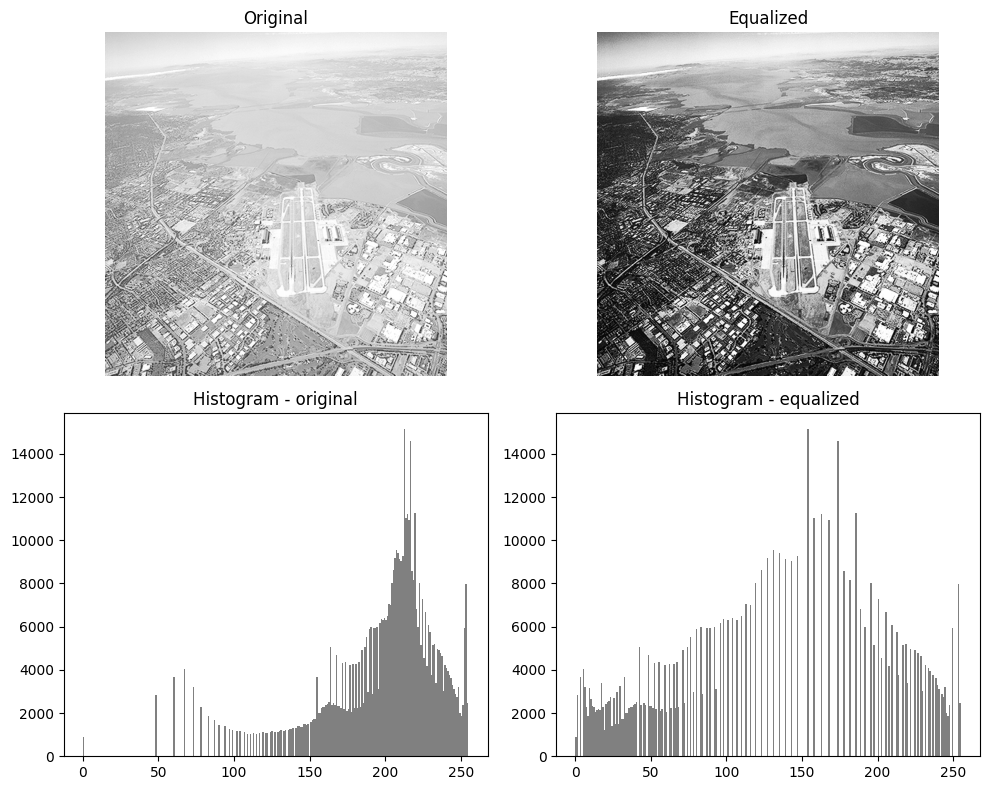

In [4]:
# top row: before and after images
# bottom row: histograms — equalized one should spread more evenly across [0, 255]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(result, cmap='gray')
axes[0, 1].set_title('Equalized')
axes[0, 1].axis('off')

axes[1, 0].hist(img.ravel(), bins=256, range=(0, 255), color='gray')
axes[1, 0].set_title('Histogram - original')

axes[1, 1].hist(result.ravel(), bins=256, range=(0, 255), color='gray')
axes[1, 1].set_title('Histogram - equalized')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q3_histeq.png'), dpi=150)
plt.show()